# Notebook 03 — Cálculo de NDVI

NDVI (Normalized Difference Vegetation Index) = (NIR − RED) / (NIR + RED)

Para Sentinel-2 L2A: `NDVI = (B08 − B04) / (B08 + B04)`.
Los valores van de -1 a 1, donde valores altos (~0.6-0.9) indican vegetación vigorosa.

**Salidas**: `media/03_ndvi.png`, `media/03_ndvi_hist.png`, `media/03_ndvi_overlay.png`

In [1]:
from pathlib import Path
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import json

def find_taller_root(start: Path, marker: str = "python/data/bogota_sabana_sentinel2.tif") -> Path:
    p = start.resolve()
    for parent in [p, *p.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"No se encontró {marker} desde {start}")

ROOT = find_taller_root(Path.cwd())
os.chdir(ROOT)
DATA = ROOT / "python" / "data"
MEDIA = ROOT / "media"
MEDIA.mkdir(exist_ok=True)

tif = DATA / "bogota_sabana_sentinel2.tif"
print("Archivo:", tif)

Archivo: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales/python/data/bogota_sabana_sentinel2.tif


In [2]:
with rasterio.open(tif) as src:
    b04 = src.read(3).astype(np.float32)  # Red
    b08 = src.read(4).astype(np.float32)  # NIR
    bounds = src.bounds
    transform = src.transform
    crs = src.crs
    profile = src.profile

np.seterr(divide="ignore", invalid="ignore")
ndvi = (b08 - b04) / (b08 + b04)
ndvi_masked = np.ma.masked_invalid(ndvi)

print(f"B04 (Red)  rango: [{b04.min():.0f}, {b04.max():.0f}]")
print(f"B08 (NIR)  rango: [{b08.min():.0f}, {b08.max():.0f}]")
print(f"NDVI       rango: [{ndvi_masked.min():.3f}, {ndvi_masked.max():.3f}]")
print(f"NDVI media: {ndvi_masked.mean():.3f}")
print(f"NDVI std:   {ndvi_masked.std():.3f}")
print(f"Bounds:     {bounds}")

B04 (Red)  rango: [1091, 7011]
B08 (NIR)  rango: [1048, 6783]
NDVI       rango: [-0.080, 0.677]
NDVI media: 0.316
NDVI std:   0.153
Bounds:     BoundingBox(left=-74.25038794439317, bottom=4.4994429744475015, right=-73.89943073843078, top=4.820514192456842)


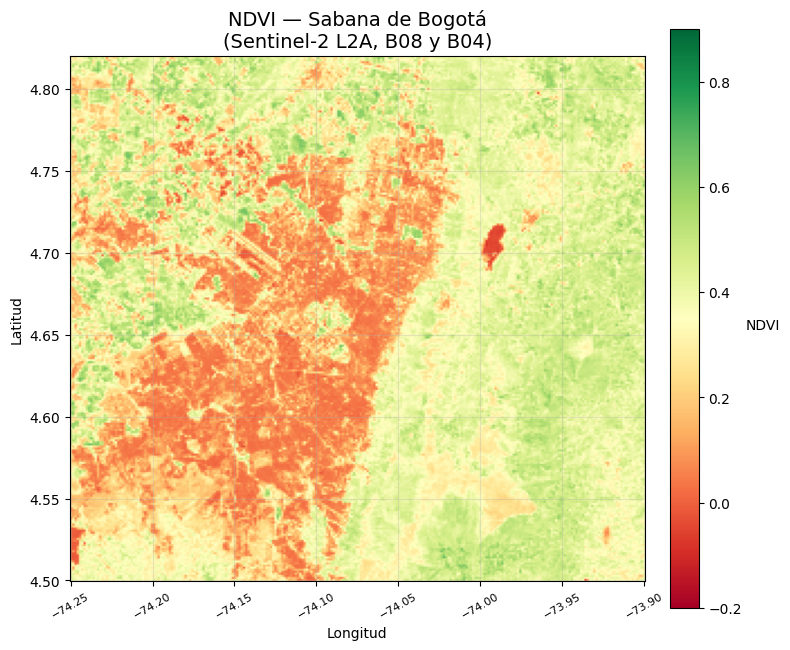

Guardado: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales/media/03_ndvi.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(
    ndvi_masked,
    cmap="RdYlGn",
    vmin=-0.2, vmax=0.9,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("NDVI", rotation=0, labelpad=15)
ax.set_title("NDVI — Sabana de Bogotá\n(Sentinel-2 L2A, B08 y B04)", fontsize=14)
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.grid(True, alpha=0.3)
plt.gca().tick_params(axis="x", rotation=30, labelsize=8)

plt.tight_layout()
out = MEDIA / "03_ndvi.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {out}")

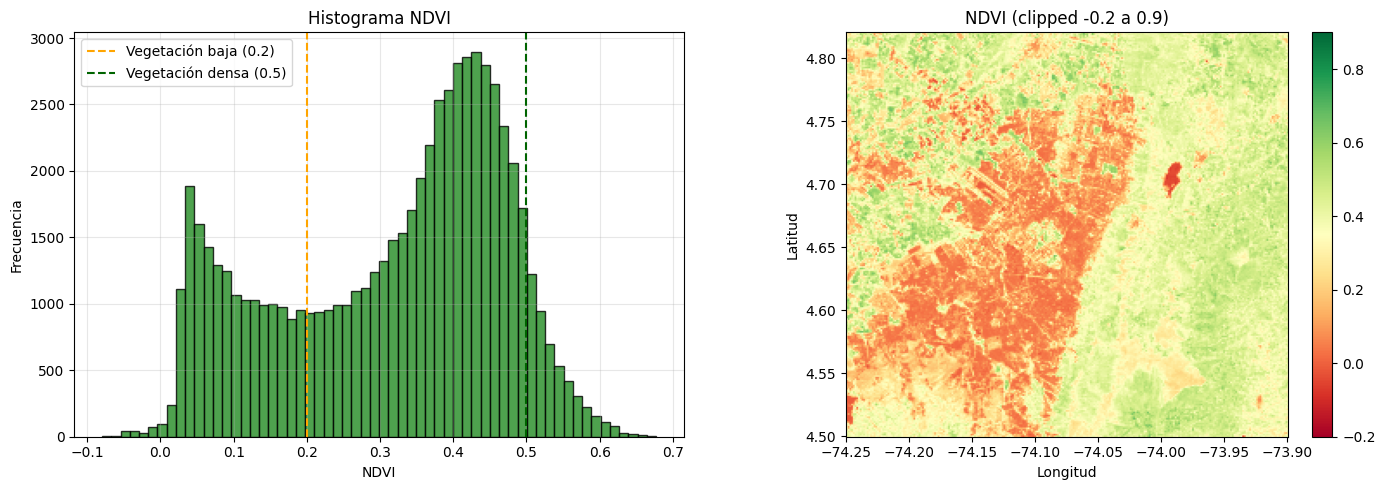

Guardado: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales/media/03_ndvi_hist.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ndvi_masked.compressed(), bins=60, color="forestgreen", edgecolor="black", alpha=0.8)
axes[0].axvline(0.2, color="orange", linestyle="--", label="Vegetación baja (0.2)")
axes[0].axvline(0.5, color="darkgreen", linestyle="--", label="Vegetación densa (0.5)")
axes[0].set_title("Histograma NDVI")
axes[0].set_xlabel("NDVI"); axes[0].set_ylabel("Frecuencia")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ndvi_clip = np.clip(ndvi_masked, -0.2, 0.9)
im = axes[1].imshow(
    ndvi_clip,
    cmap="RdYlGn",
    vmin=-0.2, vmax=0.9,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
)
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_title("NDVI (clipped -0.2 a 0.9)")
axes[1].set_xlabel("Longitud"); axes[1].set_ylabel("Latitud")
plt.tight_layout()
out = MEDIA / "03_ndvi_hist.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {out}")

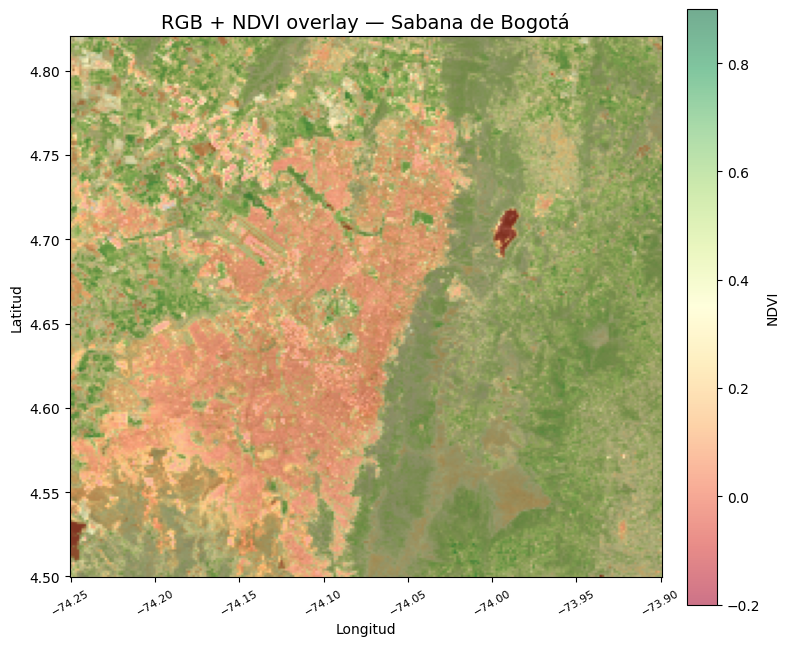

Guardado: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales/media/03_ndvi_overlay.png


In [5]:
with rasterio.open(tif) as src:
    b02 = src.read(1).astype(np.float32)
    b03 = src.read(2).astype(np.float32)
    b04 = src.read(3).astype(np.float32)

rgb = np.stack([b04, b03, b02], axis=-1)
vmin, vmax = np.nanpercentile(rgb, [2, 98])
rgb_stretched = np.clip((rgb - vmin) / (vmax - vmin), 0, 1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_stretched, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
ndvi_clip = np.clip(ndvi, -0.2, 0.9)
im = ax.imshow(
    ndvi_clip,
    cmap="RdYlGn",
    vmin=-0.2, vmax=0.9,
    alpha=0.55,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="NDVI")
ax.set_title("RGB + NDVI overlay — Sabana de Bogotá", fontsize=14)
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
plt.gca().tick_params(axis="x", rotation=30, labelsize=8)

plt.tight_layout()
out = MEDIA / "03_ndvi_overlay.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {out}")

In [6]:
out_tif = DATA / "ndvi_bogota_sabana.tif"
ndvi_to_save = np.where(np.isfinite(ndvi), ndvi, -9999.0).astype(np.float32)
out_profile = profile.copy()
out_profile.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")
with rasterio.open(out_tif, "w", **out_profile) as dst:
    dst.write(ndvi_to_save, 1)
    dst.set_band_description(1, "NDVI")
print(f"NDVI raster guardado: {out_tif} ({out_tif.stat().st_size/1024:.1f} KB)")

stats = {
    "ndvi_min": float(ndvi_masked.min()),
    "ndvi_max": float(ndvi_masked.max()),
    "ndvi_mean": float(ndvi_masked.mean()),
    "ndvi_std": float(ndvi_masked.std()),
    "bounds": [bounds.left, bounds.bottom, bounds.right, bounds.top],
    "crs": str(crs),
}
with open(DATA / "ndvi_stats.json", "w") as f:
    json.dump(stats, f, indent=2)
print("Estadísticas NDVI guardadas en ndvi_stats.json")

NDVI raster guardado: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales/python/data/ndvi_bogota_sabana.tif (288.8 KB)
Estadísticas NDVI guardadas en ndvi_stats.json


## Conclusiones

- NDVI calculado a partir de Sentinel-2 L2A (B08 y B04) con dtype `uint16` y reflectancia ×10000.
- Valores altos (rojo-amarillo-verde) en zonas con vegetación; valores bajos (rojo) en zonas urbanas o cuerpos de agua.
- Se guarda el raster NDVI y sus estadísticas para que el notebook 05 lo reuse como overlay.